In [1]:
%load_ext autoreload
%autoreload 2

### Setup

In [2]:
import os, sys
sys.path.append(os.path.dirname(os.getcwd())) # Add the parent directory to sys.path
sys.path.append('/Users/dhei/ai2/new-evals/olmo-repos/olmo/scripts') # Add the parent directory to sys.path
sys.path.append('/Users/dhei/ai2/new-evals/olmo-repos/olmo/scripts/scaling')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils import DATA_DIR, ROOT_DIR
from dataloader import get_nd_array, get_slice

from download.weka import pull_predictions_from_weka

import ladder
plt.close()

In [3]:
pull_predictions_from_weka("consistent_ranking")

File already exists and matches size: /Users/dhei/ai2/new-evals/analysis/data/all_consistent_ranking_predictions.parquet


In [4]:
# load a subset of columns to save on memory
COLS = ['step', 'model', 'task', 'mix', 'size', 'token_ratio', 'native_id']
COLS += ['acc_per_char', 'correct_choice'] # accuracy benchmarks

COLS += ['logits_per_char', 'sum_logits']
# COLS += ['logits_per_byte', 'logits_per_byte_corr', 'logits_per_char_corr']

df = pd.read_parquet(f'{DATA_DIR}/all_consistent_ranking_predictions.parquet.bak', columns=COLS)
print(f'Loaded {len(df):,} instance predictions')

Loaded 114,524,590 instance predictions


In [5]:
MODELS = df.index.get_level_values('model').unique().to_list()
TASKS  = df.index.get_level_values('task').unique().to_list()
MIXES  = df.index.get_level_values('mix').unique().to_list()
SIZES  = df['size'].unique()
TOKEN_RATIO = df['token_ratio'].unique()

MMLU  = [t for t in TASKS if 'mmlu' in t]
TASKS = [t for t in TASKS if 'mmlu' not in t and ':para' not in t]
TASKS = sorted(TASKS)

### Running the Model Ladder

In [6]:
ladder_config_path = f'{ROOT_DIR}/olmo-repos/OLMo/scripts/scaling/cheap_decisions.json'

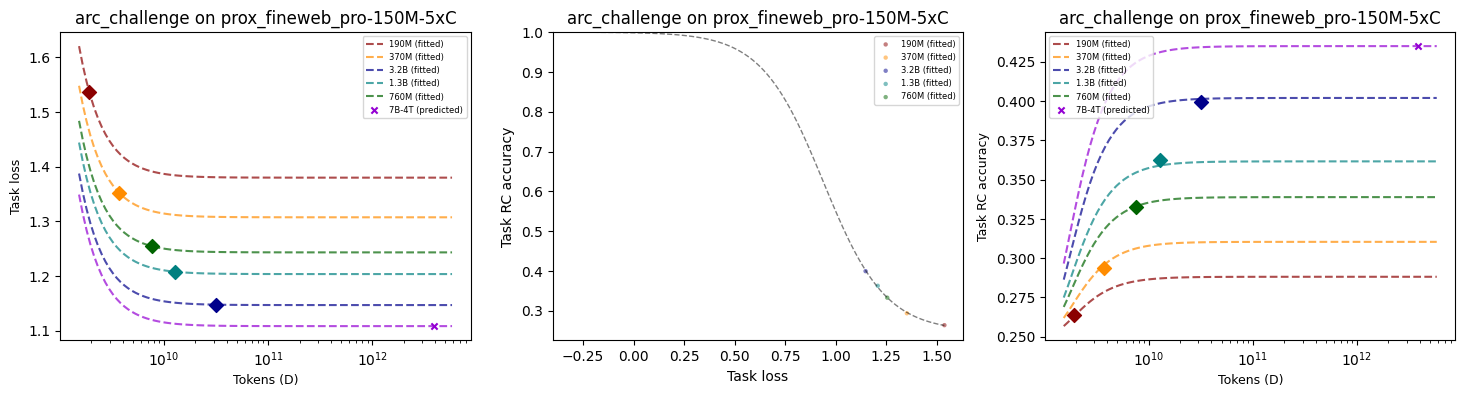

In [ ]:
import matplotlib.pyplot as plt
from ladder import run_ladder

fig, axes = plt.subplots(1, 3, figsize=(6*3, 4), squeeze=False)

task_name = "arc_challenge"
example_models = [m for m in MODELS if 'prox_fineweb_pro' in m]
_, _, _ = run_ladder(
    df,
    task_name,
    train_models=example_models,
    # eval_models=["peteish7", "peteish13-highlr"],
    eval_models=["peteish7"],
    # eval_models=[],
    config_path=ladder_config_path,
    axes=axes[0],
)

for ax in axes[0]:
    ax.set_title(f'{task_name} on {example_models[0]}')

python(39310) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Fitting model ladder predictions: 100%|██████████| 9/9 [00:04<00:00,  1.87it/s]


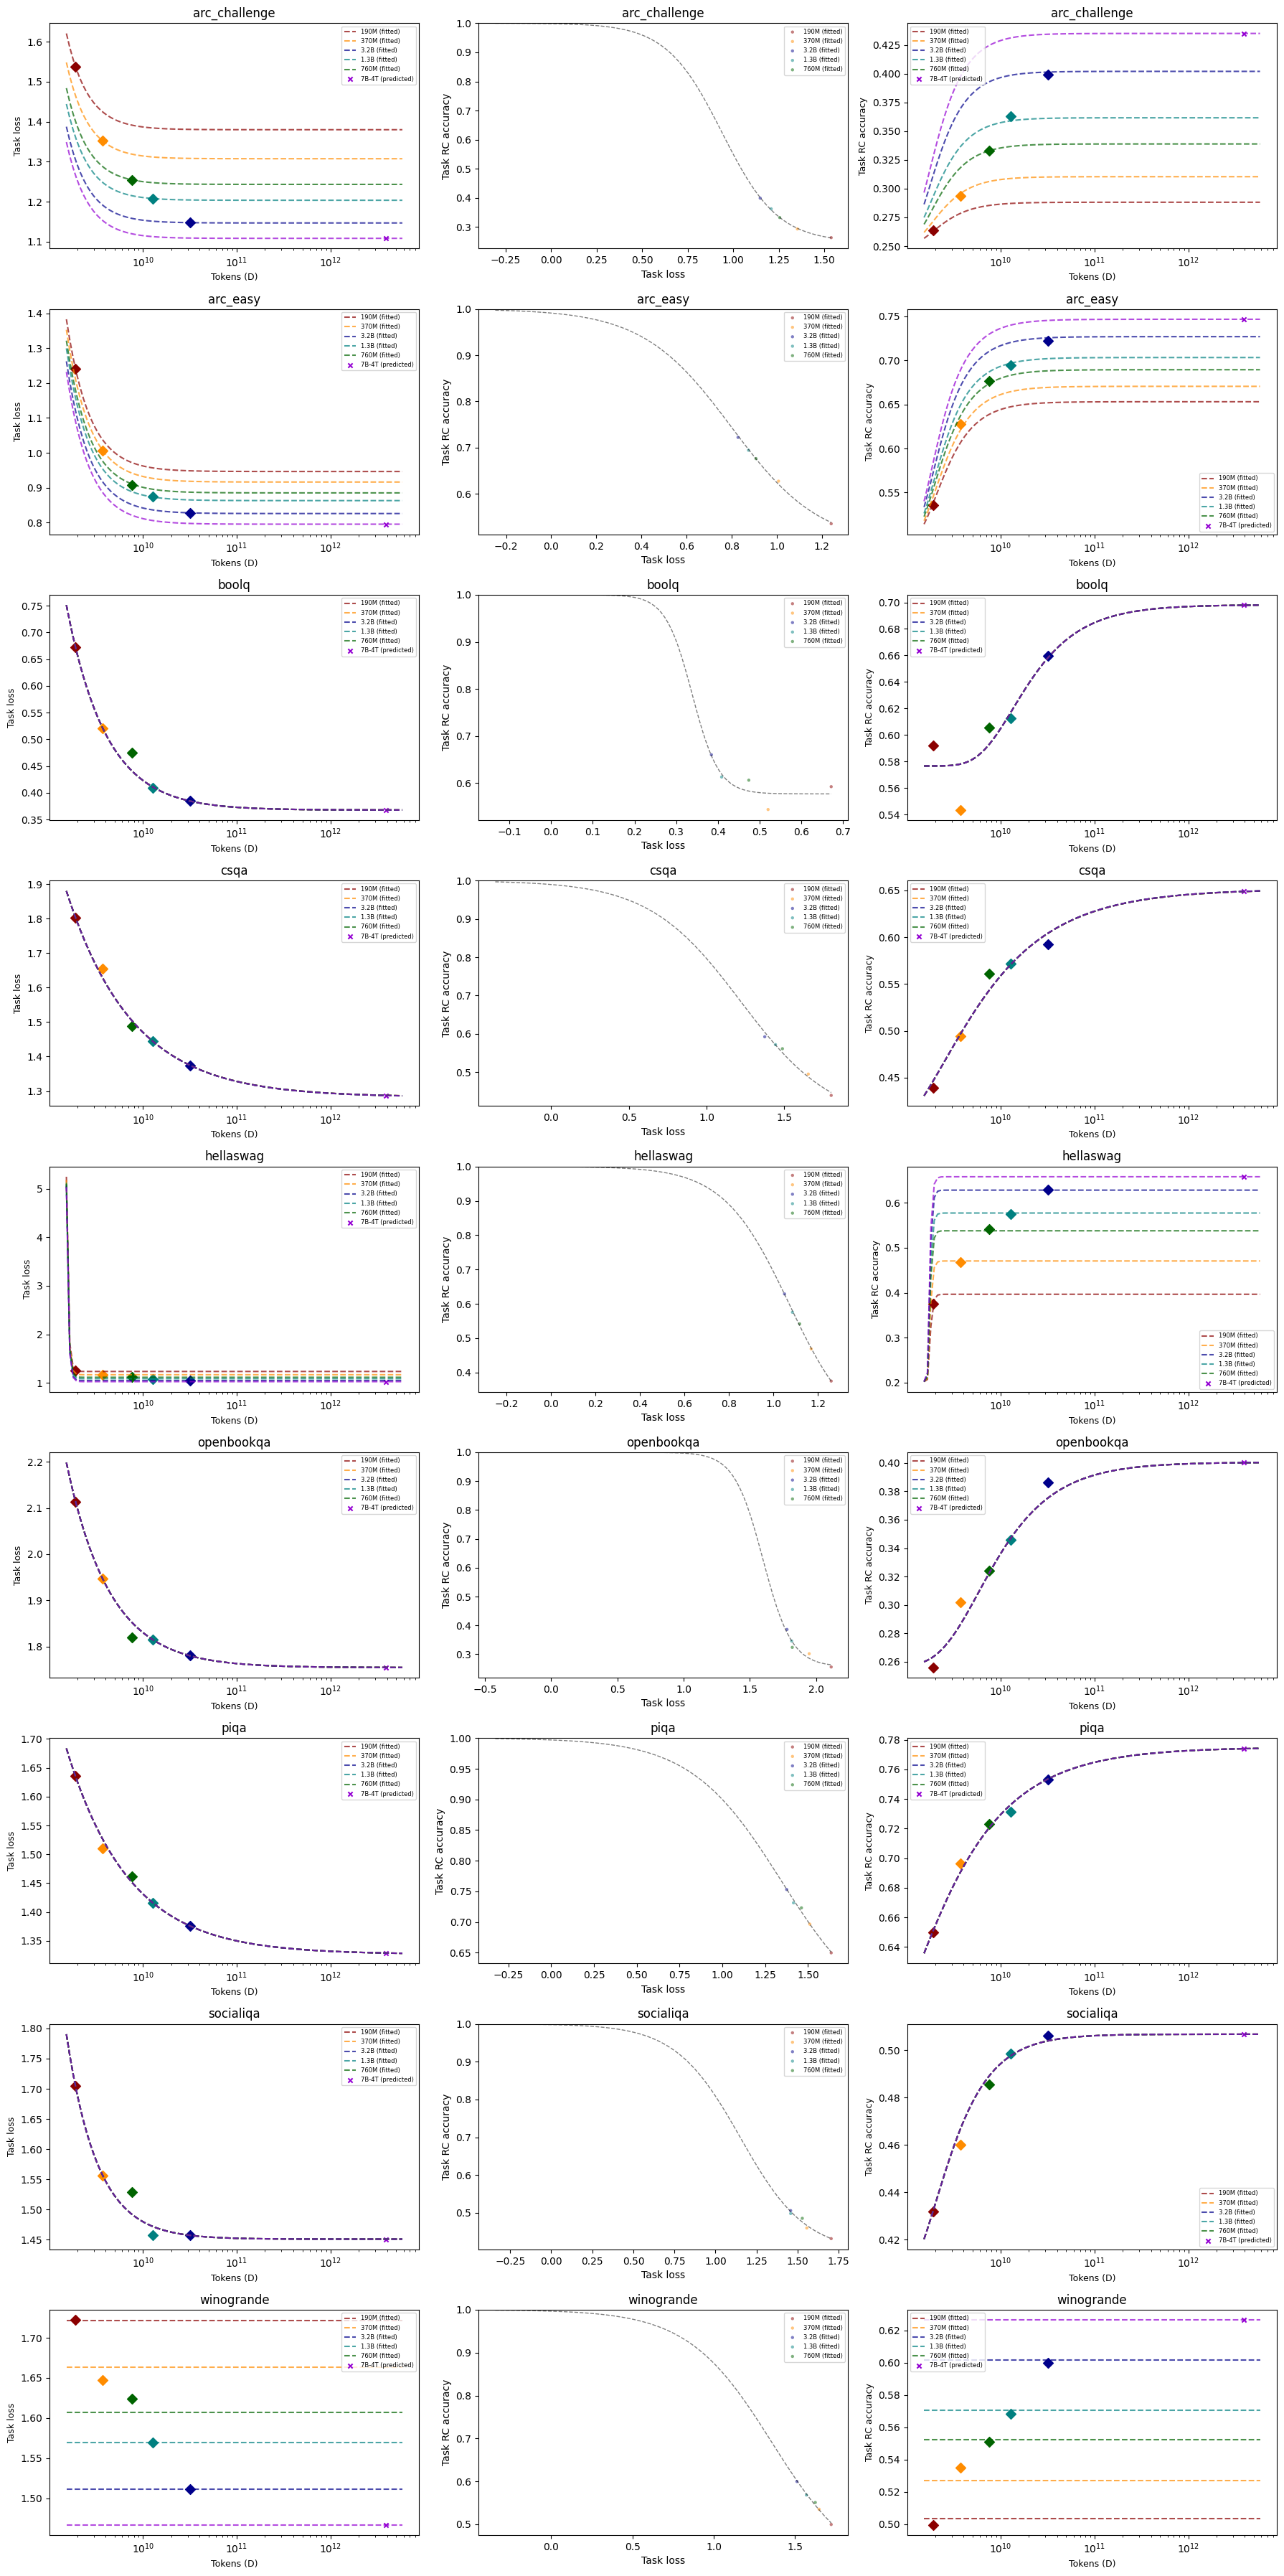

In [9]:
from tqdm import tqdm

num_rows, num_cols = len(TASKS), 3
fig, axes = plt.subplots(num_rows, num_cols, figsize=(6 * num_cols, 4 * num_rows), squeeze=False)

fitting_results = pd.DataFrame(index=[], columns=TASKS)

for i, task in tqdm(enumerate(TASKS), desc='Fitting model ladder predictions', total=len(TASKS)):
    try:
        _, _, _ = run_ladder(
            df,
            task_name=task,
            train_models=example_models,
            eval_models=["peteish7"], # ["peteish13-highlr"],
            config_path=ladder_config_path,
            axes=axes[i],
        )
    except Exception as e:
        print(f'{task} failed: {e}')
        continue

fig.tight_layout()

### Results on All Mixes

In [10]:
from tqdm import tqdm

fitting_results = pd.DataFrame(index=[], columns=TASKS)

for mix in tqdm(MIXES, desc='Fitting model ladder predictions', total=len(MIXES)):
    models = [model for model in MODELS if '-'.join(model.split('-')[:-2]) == mix]

    for i, task in enumerate(TASKS):
        _, _, pred_acc = run_ladder(
            df,
            task_name=task,
            train_models=models,
            eval_models=["peteish7"], # ["peteish13-highlr"],
            config_path=ladder_config_path,
            return_preds=True
        )

        fitting_results.loc[mix, task] = pred_acc

Fitting model ladder predictions:  10%|█         | 2/20 [00:08<01:19,  4.44s/it]/Users/dhei/ai2/new-evals/olmo-repos/olmo/olmo/scaling/scaling_laws/fitting_functions.py:333: RuntimeWarning: overflow encountered in exp
  o = a / (1 + np.exp(-k * (x - x0))) + b
Fitting model ladder predictions:  25%|██▌       | 5/20 [00:22<01:08,  4.54s/it]/Users/dhei/ai2/new-evals/olmo-repos/olmo/olmo/scaling/scaling_laws/fitting_functions.py:83: RuntimeWarning: overflow encountered in exp
  return np.exp(p[0] - np.log(x[0]) * p[2]) + np.exp(p[1] - np.log(x[1]) * p[3]) + p[4]
/Users/dhei/ai2/new-evals/olmo-repos/olmo/olmo/scaling/scaling_laws/fitting_functions.py:89: RuntimeWarning: overflow encountered in exp
  grad_b = np.exp(p[1] - np.log(x[1]) * p[3])
/Users/dhei/ai2/new-evals/olmo-repos/olmo/olmo/scaling/scaling_laws/fitting_functions.py:91: RuntimeWarning: overflow encountered in exp
  grad_beta = np.exp(p[1] - np.log(x[1]) * p[3]) * (-np.log(x[1]))
/Users/dhei/ai2/new-evals/olmo-repos/olmo/olmo/s

In [12]:
print('Predicted performance for 7B-4T on all mixes:')
fitting_results['macro_avg'] = fitting_results.mean(axis=1)
fitting_results = fitting_results.sort_values(by='macro_avg', ascending=False)
fitting_results_display = fitting_results.map(lambda x: f'{round(x * 100, 1)}%')
fitting_results_display

Predicted performance for 7B-4T on all mixes:


,arc_challenge,arc_easy,boolq,csqa,hellaswag,openbookqa,piqa,socialiqa,winogrande,macro_avg
falcon_and_cc_og_eli5_oh_top10p,45.4%,75.3%,100.0%,68.8%,71.9%,40.1%,77.9%,51.8%,66.8%,66.5%
dolma17-50p-DCLM-baseline-50p,42.2%,74.6%,61.0%,59.9%,68.1%,83.0%,80.1%,55.6%,66.8%,65.7%
falcon_and_cc_eli5_oh_top20p,45.6%,76.1%,92.6%,67.2%,71.3%,39.8%,79.5%,53.3%,64.0%,65.5%
fineweb_edu_dedup,46.0%,74.7%,77.7%,84.1%,66.1%,38.3%,76.2%,55.6%,61.9%,64.5%
DCLM-baseline,45.5%,74.6%,79.1%,65.1%,67.4%,38.8%,78.6%,54.9%,62.3%,62.9%
dolma17-25p-DCLM-baseline-75p,44.6%,75.4%,61.7%,63.3%,68.9%,43.2%,78.8%,54.9%,64.2%,61.7%
falcon,37.9%,72.0%,79.1%,61.6%,68.4%,36.6%,79.0%,57.8%,62.5%,61.7%
falcon_and_cc_eli5_oh_top10p,43.6%,74.9%,64.0%,66.1%,69.2%,37.7%,78.6%,54.8%,65.6%,61.6%
c4,37.7%,67.9%,66.2%,61.8%,86.8%,33.7%,80.6%,50.4%,64.8%,61.1%
prox_fineweb_pro,43.5%,74.7%,69.8%,64.9%,65.8%,40.0%,77.4%,50.7%,62.6%,61.0%
